# <a name = 'Data Aquisition' style="color:#000000;"><u> Data Aquisition </u></a>



<u><b>Crime, Stop and Search Data:</b></u>
- <b> Source:</b> <a href = https://data.police.uk/data/> UK Police Data </a>
- <b> Data type:</b> CSV File
- <b> Aquried through :</b> Downloading and Merging CSV Files

<u><b>Geographic Data:</b></u>
- <b> Source:</b> <a href = https://zenodo.org/records/6395804> Original local authority shapes, based on 2011 census - UK Data Service</a>
- <b> Data type:</b> Shapefile
- <b> Aquried through :</b> Downloading Shapefile



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!pip install pmdarima --quiet

In [9]:
#Importing Libraries as Needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import geopandas as gpd
import requests
import statsmodels.api as sm
# import pmdarima as pm
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from bs4 import BeautifulSoup
from io import BytesIO
from datetime import datetime

## Crime Data

#### Note:

The crime data from the UK Police site stores each cities information in a different csv file. The below code aims to aggregate street data stored in the separate csv files.

In [54]:
import os
base_path = "/content/drive/MyDrive/UK_Crime_dataset/2022-08"

# Function to combine all 'street.csv' files
def combine_street_data(base_path):
    dfs = []  # List to store each dataframe temporarily
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('street.csv'):
                file_path = os.path.join(root, file)
                df = pd.read_csv(file_path, encoding='latin-1')
                # Append it to the list of dataframes
                dfs.append(df)
    # combine all dataframes in the list into one dataframe
    combined_df = pd.concat(dfs, ignore_index = True)
    return combined_df

combined_df = combine_street_data(base_path)
combined_df.rename(columns = {'Reported by': 'Reported by and Falls within', 'Month': 'Date'}, inplace = True)

combined_df['Date'] = pd.to_datetime(combined_df['Date']).apply(lambda d: d.replace(day = 1))
combined_df.drop(columns = 'Falls within', inplace = True)


In [11]:
!pip install pmdarima --quiet

In [12]:
# Reading the crime data as a dataframe df_crime
#df_crime = pd.read_csv("combined_df.csv")
df_crime= combined_df
df_crime.head()

,Crime ID,Date,Reported by and Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
1,NaN,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
2,NaN,2022-08-01,Avon and Somerset Constabulary,-2.513516,51.408799,On or near Lincoln Close,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
3,NaN,2022-08-01,Avon and Somerset Constabulary,-2.51437,51.409298,On or near Lays Drive,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
4,NaN,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN


## Stop and Search Data

We used a similar approach to obtain stop and search data

In [13]:
# base_path = "/content/drive/MyDrive/umer_hayat/crime_data/new data/2022-08"

# Function to combine all 'search.csv' files
def combine_search_data(base_path):
    dfs = []  # List to store each dataframe temporarily
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('search.csv'):
                file_path = os.path.join(root, file)
                # Read the current csv file into a dataframe
                df = pd.read_csv(file_path, encoding='latin-1')
                # Append it to the list of dataframes
                dfs.append(df)
    # combine all dataframes in the list into one dataframe
    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df

# Combine the data
combined_search_df = combine_search_data(base_path)
combined_search_df.head()


,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing
0,Person search,2022-08-01T00:49:00+00:00,NaN,NaN,51.46182,-2.563052,Male,over 34,NaN,White,Police and Criminal Evidence Act 1984 (section 1),Article for use in theft,A no further action disposal,False,False
1,Vehicle search,2022-08-01T01:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Misuse of Drugs Act 1971 (section 23),NaN,NaN,NaN,NaN
2,Person search,2022-08-01T10:43:00+00:00,NaN,NaN,51.462213,-2.59101,Male,over 34,White - Any other White background,White,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal,NaN,False
3,Person search,2022-08-01T16:33:00+00:00,NaN,NaN,51.456677,-2.592162,Male,18-24,Mixed/Multiple ethnic groups - Any other Mixed...,Mixed,Police and Criminal Evidence Act 1984 (section 1),Articles for use in criminal damage,A no further action disposal,True,False
4,Person search,2022-08-01T16:40:00+00:00,NaN,NaN,51.345692,-2.972984,Female,25-34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,True,False


## UK ShapeFile by District

In [14]:
# Reading the geographic dataframe
gdf_Districts = gpd.read_file("/content/drive/MyDrive/UK_Crime_dataset/2022-08/2011_censos/infuse_dist_lyr_2011/infuse_dist_lyr_2011.shp")
gdf_Districts

,geo_code,geo_label,geo_labelw,label,name,geometry
0,W06000016,Rhondda Cynon Taf,Rhondda Cynon Taf,W92000004W06000016,Rhondda Cynon Taf,"POLYGON ((291902.5 196289.607, 291899.094 1962..."
1,S12000013,Eilean Siar,None,S92000003S12000013,Eilean Siar,"MULTIPOLYGON (((138021.5 955416.2, 138026.2 95..."
2,W06000013,Bridgend,Pen-y-bont ar Ogwr,W92000004W06000013,Bridgend,"POLYGON ((280647.356 182792.75, 280647.402 182..."
3,E07000138,Lincoln,None,E92000001E07000138,Lincoln,"POLYGON ((495362.339 373435.025, 495367.034 37..."
4,E07000166,Richmondshire,None,E92000001E07000166,Richmondshire,"POLYGON ((392540.053 507436.934, 392689 507651..."
...,...,...,...,...,...,...
399,E07000049,East Dorset,None,E92000001E07000049,East Dorset,"POLYGON ((397287.219 107318.047, 397285.693 10..."
400,E07000046,Torridge,None,E92000001E07000046,Torridge,"MULTIPOLYGON (((240262.906 127104.094, 240265...."
401,E06000004,Stockton-on-Tees,None,E92000001E06000004,Stockton-on-Tees,"POLYGON ((438392.691 522207.088, 438392.094 52..."
402,S12000024,Perth & Kinross,None,S92000003S12000024,Perth & Kinross,"POLYGON ((318569.723 758407.776, 318676.587 75..."


# <a name = 'Data Preprocessing' style="color:#000000;"><u> Data Preprocessing </u></a>

## Crime Data

In [15]:
#Head of Crime Dataset

df_crime.head()

,Crime ID,Date,Reported by and Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
1,NaN,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
2,NaN,2022-08-01,Avon and Somerset Constabulary,-2.513516,51.408799,On or near Lincoln Close,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
3,NaN,2022-08-01,Avon and Somerset Constabulary,-2.51437,51.409298,On or near Lays Drive,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
4,NaN,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN


#### Handling the missing values

In [16]:
#Checking Missing Percentages in Crime Dataset
missing_data_crime = (df_crime.isnull().sum() / len(df_crime)) * 100
missing_data_crime

,0
Crime ID,15.549573
Date,0.000000
Reported by and Falls within,0.000000
Longitude,4.599526
Latitude,5.147143
Location,0.547617
LSOA code,4.599526
LSOA name,4.615632
Crime type,0.547617
Last outcome category,16.081084


In [17]:
# Dropping the columns with more than 10% missing value
drop = ['Crime ID', 'Last outcome category','Context']
df_crime = df_crime.drop(columns = drop, axis = 1)
df_crime.head()

,Date,Reported by and Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type
0,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour
1,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour
2,2022-08-01,Avon and Somerset Constabulary,-2.513516,51.408799,On or near Lincoln Close,E01014399,Bath and North East Somerset 001A,Anti-social behaviour
3,2022-08-01,Avon and Somerset Constabulary,-2.51437,51.409298,On or near Lays Drive,E01014399,Bath and North East Somerset 001A,Anti-social behaviour
4,2022-08-01,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour


In [18]:
# Dropping the rows with missing values
df_crime = df_crime.dropna()

In [19]:
df_crime.isnull().sum()

,0
Date,0
Reported by and Falls within,0
Longitude,0
Latitude,0
Location,0
LSOA code,0
LSOA name,0
Crime type,0


The missing values are handled

#### Grouping the data by District

In [20]:
# Dropping the rows with missing values
df_crime = df_crime.dropna()

#Cleaning LSOA name to match District shapefile names - removing digits
df_crime.loc[:, 'District'] = df_crime['LSOA name'].str.extract(r'(\D+)(\d+)')[0]

#Grouping dataset by District to create sub dataframe
count = df_crime.groupby('District').size().reset_index(name = 'Crime Count')

# Convert 'Longitude' and 'Latitude' to numeric
# The errors='coerce' argument will convert invalid parsing to NaN
df_crime['Longitude'] = pd.to_numeric(df_crime['Longitude'], errors='coerce')
df_crime['Latitude'] = pd.to_numeric(df_crime['Latitude'], errors='coerce')

#Filling the longitude and latitude with the mean values
long_lat_df = df_crime.groupby('District')[['Longitude', 'Latitude']].mean().reset_index()
df_District = pd.merge(count, long_lat_df, on = 'District')
df_District['District'] = df_District['District'].str.strip()
df_District.columns = ['District', 'Crime Count', 'Longitude', 'Latitude']
df_District.sort_values("Crime Count",ascending=False).head()

,District,Crime Count,Longitude,Latitude
7,Bristol,10531,-2.586915,51.457936
56,Peterborough,4824,-0.252982,52.578941
69,South Gloucestershire,3344,-2.508222,51.509535
54,North Somerset,2941,-2.885772,51.379118
9,Cambridge,2743,0.134739,52.205677


In [21]:
# #Renaming District Names (To match the shapefile district names)
# df_District['District'] = df_District['District'].str.lower()
# df_District.loc[df_District['District'] == 'bristol', 'District'] = 'bristol, city of'
# df_District.loc[df_District['District'] == 'west suffolk', 'District'] = 'mid suffolk'
# df_District.loc[df_District['District'] == 'east suffolk', 'District'] = 'suffolk coastal'
# df_District.loc[df_District['District'] == 'bournemouth, christchurch and poole', 'District'] = 'bournemouth'
# df_District.loc[df_District['District'] == 'cornwall', 'District'] = 'cornwall,isles of scilly'
# df_District.loc[df_District['District'] == 'dorset', 'District'] = 'north dorset'
# df_District.loc[df_District['District'] == 'herefordshire', 'District'] = 'herefordshire, county of'
# df_District.loc[df_District['District'] == 'kingston upon hull', 'District'] = 'kingston upon hull, city of'
# df_District.loc[df_District['District'] == 'north northamptonshire', 'District'] = 'east northamptonshire'
# df_District.loc[df_District['District'] == 'west northamptonshire', 'District'] = 'south northamptonshire'
# df_District.loc[df_District['District'] == 'somerset west and taunton', 'District'] = 'west somerset'
# df_District.loc[df_District['District'] == 'vale of glamorgan', 'District'] = 'the vale of glamorgan'

# #Aggregating and Combining rows
# combined_rows = df_District[df_District['District'].isin(['city of London', 'westminster'])]
# combined_row = pd.DataFrame({
#     'District': ['city of london,westminster'],
#     'Crime Count': [combined_rows['Crime Count'].sum()],
#     'Latitude': [combined_rows['Latitude'].mean()],
#     'Longitude': [combined_rows['Longitude'].mean()]
# })
# df_District = pd.concat([df_District, combined_row], ignore_index = True)


## Stop and Search Data

In [22]:
#Head of Stop and Search Dataset
df_search=combined_search_df

In [23]:
# Checking Missing Percentages in Search Dataset
missing_data_1 = (df_search.isnull().sum() / len(df_search)) * 100
missing_data_1

,0
Type,0.000000
Date,0.000000
Part of a policing operation,84.516129
Policing operation,85.677419
Latitude,9.419355
Longitude,10.129032
Gender,2.774194
Age range,5.548387
Self-defined ethnicity,2.774194
Officer-defined ethnicity,4.967742


In [24]:
# Dropping the irrelavent columns with more than 50% missing value
drop_1 = ['Policing operation', 'Outcome linked to object of search','Removal of more than just outer clothing']
df_search = df_search.drop(columns = drop_1, axis = 1)
df_search.head()

,Type,Date,Part of a policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome
0,Person search,2022-08-01T00:49:00+00:00,NaN,51.46182,-2.563052,Male,over 34,NaN,White,Police and Criminal Evidence Act 1984 (section 1),Article for use in theft,A no further action disposal
1,Vehicle search,2022-08-01T01:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Misuse of Drugs Act 1971 (section 23),NaN,NaN
2,Person search,2022-08-01T10:43:00+00:00,NaN,51.462213,-2.59101,Male,over 34,White - Any other White background,White,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal
3,Person search,2022-08-01T16:33:00+00:00,NaN,51.456677,-2.592162,Male,18-24,Mixed/Multiple ethnic groups - Any other Mixed...,Mixed,Police and Criminal Evidence Act 1984 (section 1),Articles for use in criminal damage,A no further action disposal
4,Person search,2022-08-01T16:40:00+00:00,NaN,51.345692,-2.972984,Female,25-34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal


In [25]:
#Grouping the outcome of each stop and search into "severity" categories
outcome_mapping = {
    'A no further action disposal': 'Low Severity',
    'Arrest': 'High Severity',
    'Community resolution': 'Mid Severity',
    'Penalty Notice for Disorder': 'Mid Severity',
    'Summons / charged by post': 'High Severity',
    'Khat or Cannabis warning': 'Low Severity',
    'Caution (simple or conditional)': 'Mid Severity'
}

df_search.loc[:, 'Outcome_Severity'] = df_search['Outcome'].map(outcome_mapping)
df_search = df_search.dropna(subset = ['Outcome_Severity']) # Dropping the original column
df_search.head()

,Type,Date,Part of a policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome_Severity
0,Person search,2022-08-01T00:49:00+00:00,NaN,51.46182,-2.563052,Male,over 34,NaN,White,Police and Criminal Evidence Act 1984 (section 1),Article for use in theft,A no further action disposal,Low Severity
2,Person search,2022-08-01T10:43:00+00:00,NaN,51.462213,-2.59101,Male,over 34,White - Any other White background,White,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal,Low Severity
3,Person search,2022-08-01T16:33:00+00:00,NaN,51.456677,-2.592162,Male,18-24,Mixed/Multiple ethnic groups - Any other Mixed...,Mixed,Police and Criminal Evidence Act 1984 (section 1),Articles for use in criminal damage,A no further action disposal,Low Severity
4,Person search,2022-08-01T16:40:00+00:00,NaN,51.345692,-2.972984,Female,25-34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,Low Severity
5,Person search,2022-08-01T16:40:00+00:00,NaN,51.494809,-2.59102,Female,over 34,White - English/Welsh/Scottish/Northern Irish/...,White,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal,Low Severity


## UK ShapeFile by District

In [26]:
#Cleaning and Shapefile

gdf_Districts = gdf_Districts.rename(columns = {'name':'District'}) # Renaming the column
col = ['geo_code', 'geo_label', 'geo_labelw', 'label']
gdf_Districts = gdf_Districts.drop(columns = col)  # Dropping unnecessary column
gdf_Districts = gdf_Districts.sort_values(by = 'District').reset_index(drop = True) # Sorting alphbetically
gdf_Districts['District'] = gdf_Districts['District'].str.lower()
gdf_Districts.head()

,District,geometry
0,aberdeen city,"MULTIPOLYGON (((392158.559 814139.01, 392160.0..."
1,aberdeenshire,"MULTIPOLYGON (((412418.643 843809.923, 412415...."
2,adur,"POLYGON ((515970.453 104642.218, 515950.5 1046..."
3,allerdale,"POLYGON ((307327.219 542283.19, 307332.314 542..."
4,amber valley,"POLYGON ((428360.907 351278.595, 428362.813 35..."


In [27]:
gdf_Districts.isnull().sum()

,0
District,0
geometry,0


# <a name = 'Data Visualisation' style="color:#000000;"><u> Data Visualisation </u></a>

## <a name = 'Crime Data' style="color:#000000;"> Crime Data </a>

### Crime Type Analysis

We first start by investigating the distribution of crime types using the 'Crime type' column to identify the most common and least common types of crimes.

In [28]:
df_crime['Crime type'].unique()

array(['Anti-social behaviour', 'Public order',
       'Violence and sexual offences', 'Burglary',
       'Criminal damage and arson', 'Other theft', 'Shoplifting',
       'Vehicle crime', 'Other crime', 'Robbery', 'Drugs',
       'Theft from the person', 'Bicycle theft', 'Possession of weapons'],
      dtype=object)

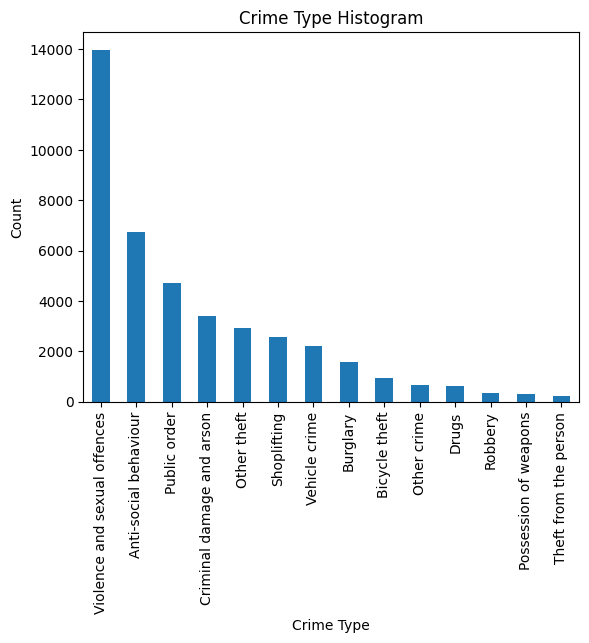

In [29]:
#Histogram detailing sum of each crime type
crime_type = df_crime['Crime type'].value_counts()
crime_type.plot(kind = 'bar')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.title('Crime Type Histogram')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.show()

The below graph is an interactive pie chart that helps visualise the count of crime type in proportion to one another. Clicking on the legend selects/deslects different crime types, thus making it customisable.

In [30]:
#Pie chart to show the percentage of each crime
pie_1 = df_crime['Crime type'].value_counts().reset_index()
pie_1.columns = ['Crime type', 'Count']
fig = px.pie(pie_1, names = 'Crime type', values = 'Count', title = 'Crime Type Proportions')
fig.show()

#### Observations

The three most prevalent crimes are 'Violence and sexual offences', 'Anti-social behaviour', and 'Public order', consisting of over 70% of the crimes. In contrast, crimes such as 'Possession of weapons', 'Robbery', and 'Bicycle theft' are minimal, each consisting of around 1% of the crimes.

identify potential correlations with nearby Police Stations and Possible Crimes

In [31]:
#Loading a data frame depicting count of 'Reported by and Falls within' by 'Crime Type'
df = df_crime.groupby(['Reported by and Falls within', 'Crime type']).size().reset_index(name='Count')
pivot_table = df.pivot(index = 'Reported by and Falls within', columns = 'Crime type', values = 'Count').fillna(0)
pivot_table.head()

Crime type,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences
Reported by and Falls within,,,,,,,,,,,,,,
Avon and Somerset Constabulary,4707,520,963,2212,309,378,1897,156,3360,220,1840,133,1450,9187
Cambridgeshire Constabulary,2040,426,594,1202,314,276,1013,138,1365,124,726,108,773,4793


In [32]:
#Storing this as a correlation matrix
z = pd.get_dummies(df)
z.corr()

,Count,Reported by and Falls within_Avon and Somerset Constabulary,Reported by and Falls within_Cambridgeshire Constabulary,Crime type_Anti-social behaviour,Crime type_Bicycle theft,Crime type_Burglary,Crime type_Criminal damage and arson,Crime type_Drugs,Crime type_Other crime,Crime type_Other theft,Crime type_Possession of weapons,Crime type_Public order,Crime type_Robbery,Crime type_Shoplifting,Crime type_Theft from the person,Crime type_Vehicle crime,Crime type_Violence and sexual offences
Count,1.000000,2.466902e-01,-2.466902e-01,2.710005e-01,-1.424389e-01,-9.889272e-02,3.345634e-02,-1.654592e-01,-1.632499e-01,-2.463918e-03,-1.889072e-01,1.268918e-01,-1.853437e-01,-2.698092e-02,-1.926845e-01,-5.142666e-02,7.864990e-01
Reported by and Falls within_Avon and Somerset Constabulary,0.246690,1.000000e+00,-1.000000e+00,6.735760e-17,1.924503e-18,4.811257e-17,4.811257e-17,4.811257e-17,1.732053e-17,-1.347152e-17,1.732053e-17,1.924503e-18,5.773509e-18,2.116953e-17,-5.196158e-17,-2.501854e-17,-4.618807e-17
Reported by and Falls within_Cambridgeshire Constabulary,-0.246690,-1.000000e+00,1.000000e+00,-3.656556e-17,2.694304e-17,-2.886754e-17,-2.886754e-17,-1.347152e-17,1.732053e-17,1.154702e-17,1.924503e-18,-1.347152e-17,-2.116953e-17,-7.505561e-17,2.886754e-17,-3.271655e-17,-1.539602e-17
Crime type_Anti-social behaviour,0.271000,6.735760e-17,-3.656556e-17,1.000000e+00,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02
Crime type_Bicycle theft,-0.142439,1.924503e-18,2.694304e-17,-7.692308e-02,1.000000e+00,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02
Crime type_Burglary,-0.098893,4.811257e-17,-2.886754e-17,-7.692308e-02,-7.692308e-02,1.000000e+00,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02
Crime type_Criminal damage and arson,0.033456,4.811257e-17,-2.886754e-17,-7.692308e-02,-7.692308e-02,-7.692308e-02,1.000000e+00,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02
Crime type_Drugs,-0.165459,4.811257e-17,-1.347152e-17,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,1.000000e+00,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02
Crime type_Other crime,-0.163250,1.732053e-17,1.732053e-17,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,1.000000e+00,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02
Crime type_Other theft,-0.002464,-1.347152e-17,1.154702e-17,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,1.000000e+00,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02,-7.692308e-02


## Density Plot by Crime Type

In the Density Plots below, we graph the density of the top 5 crime types across longitude and latitude. Doing so helps us identify hotspots within the UK correlating to a specific location and crime.

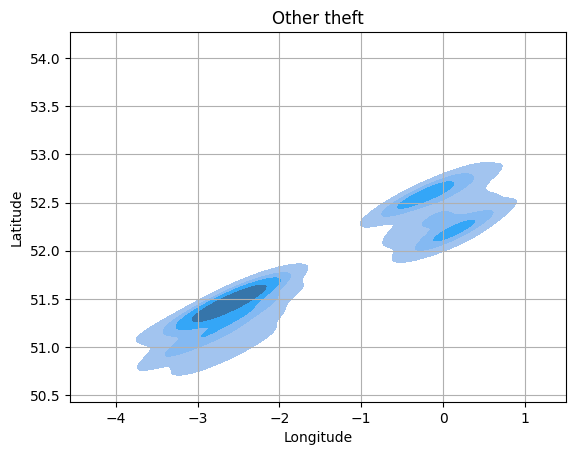

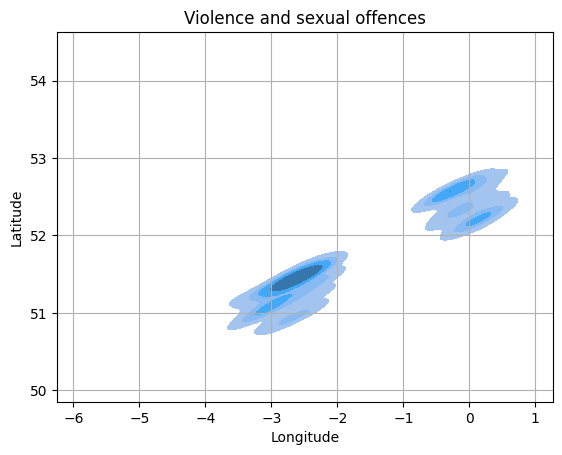

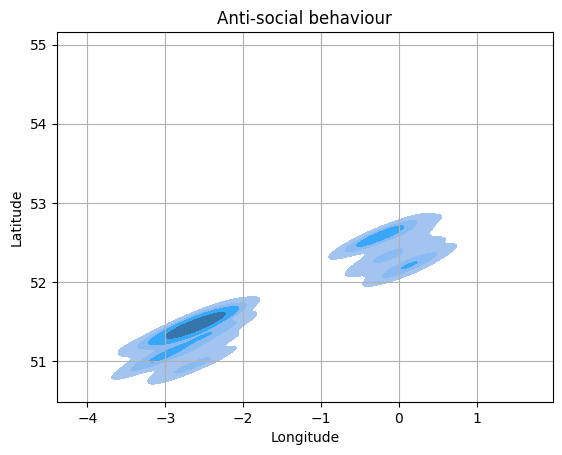

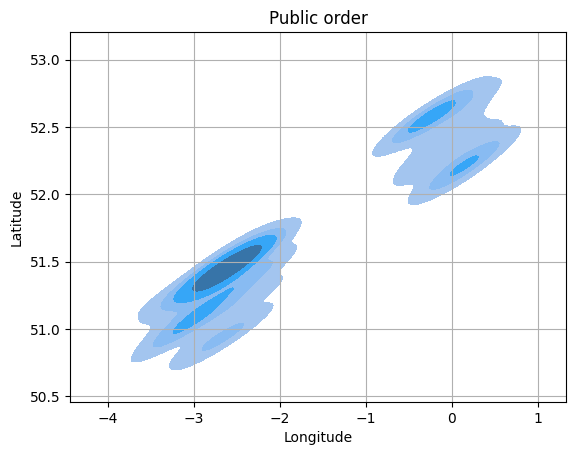

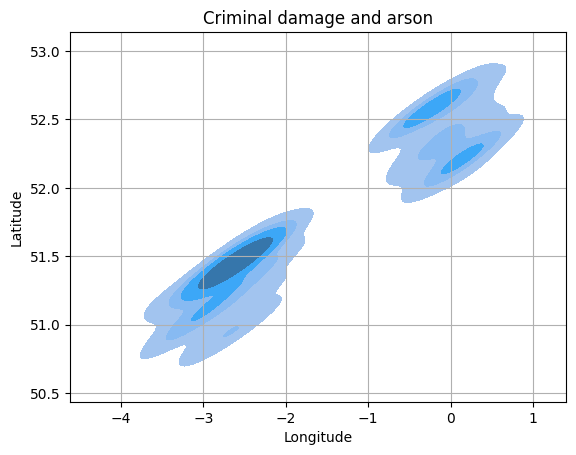

In [33]:
#Density Plot of Top 5 Crime Types along Longitude and Latitude
crime_types = ['Other theft', 'Violence and sexual offences', 'Anti-social behaviour', 'Public order','Criminal damage and arson']

#Creating a for loop to plot for each crime type
for crime in crime_types:
    crime_type_df = df_crime[df_crime['Crime type'] == crime]
    graph = sns.kdeplot(x = 'Longitude', y = 'Latitude', data = crime_type_df, fill = True, levels = 5)
    plt.grid()
    plt.title(crime)
    plt.show()

## Temporal Analysis:

Here we try to explore the temporal trends in crime incidents using the 'Date' variable. Try to identify the patterns in overal crime count along with the trends of the most common crimes.

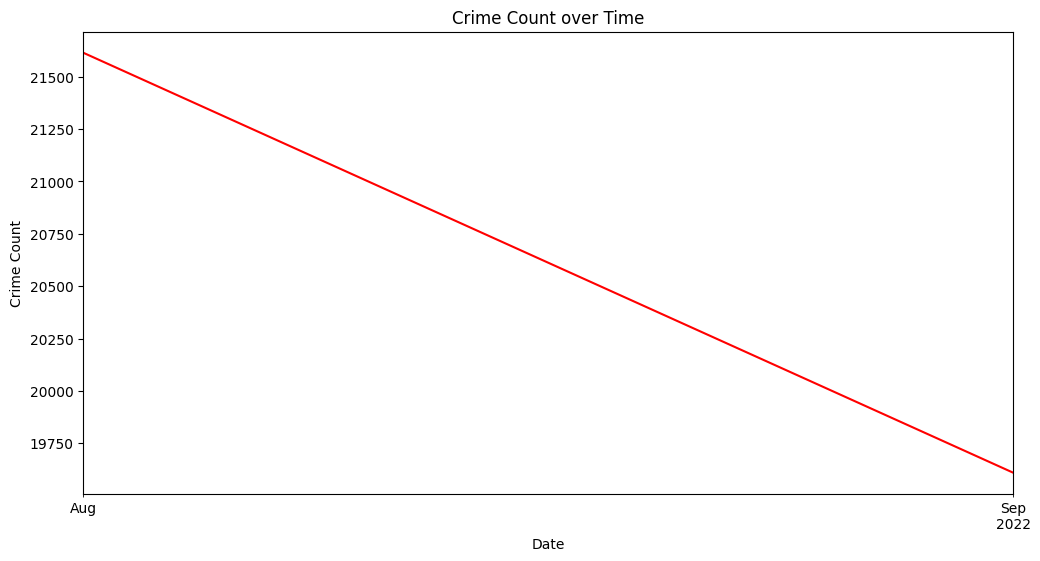

In [34]:
#Changing format of Date column. Plotting Crime Sum over Time
df_crime['Date'] = pd.to_datetime(df_crime['Date'])
df_crime['GeneralDate'] = df_crime['Date'].dt.to_period('M')
time_series = df_crime.groupby('GeneralDate').size()

time_series.plot(figsize = (12, 6), color = 'red')
plt.title('Crime Count over Time')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.show()

### Temporal Analysis by Crime Type:

We've undertaken an initiative to gain deeper insights into crime data. Our focus includes analyzing the relationship between crime types over time and creating visualizations of different crime type combinations for each police station using heatmaps. It can be seen in the below three plots.

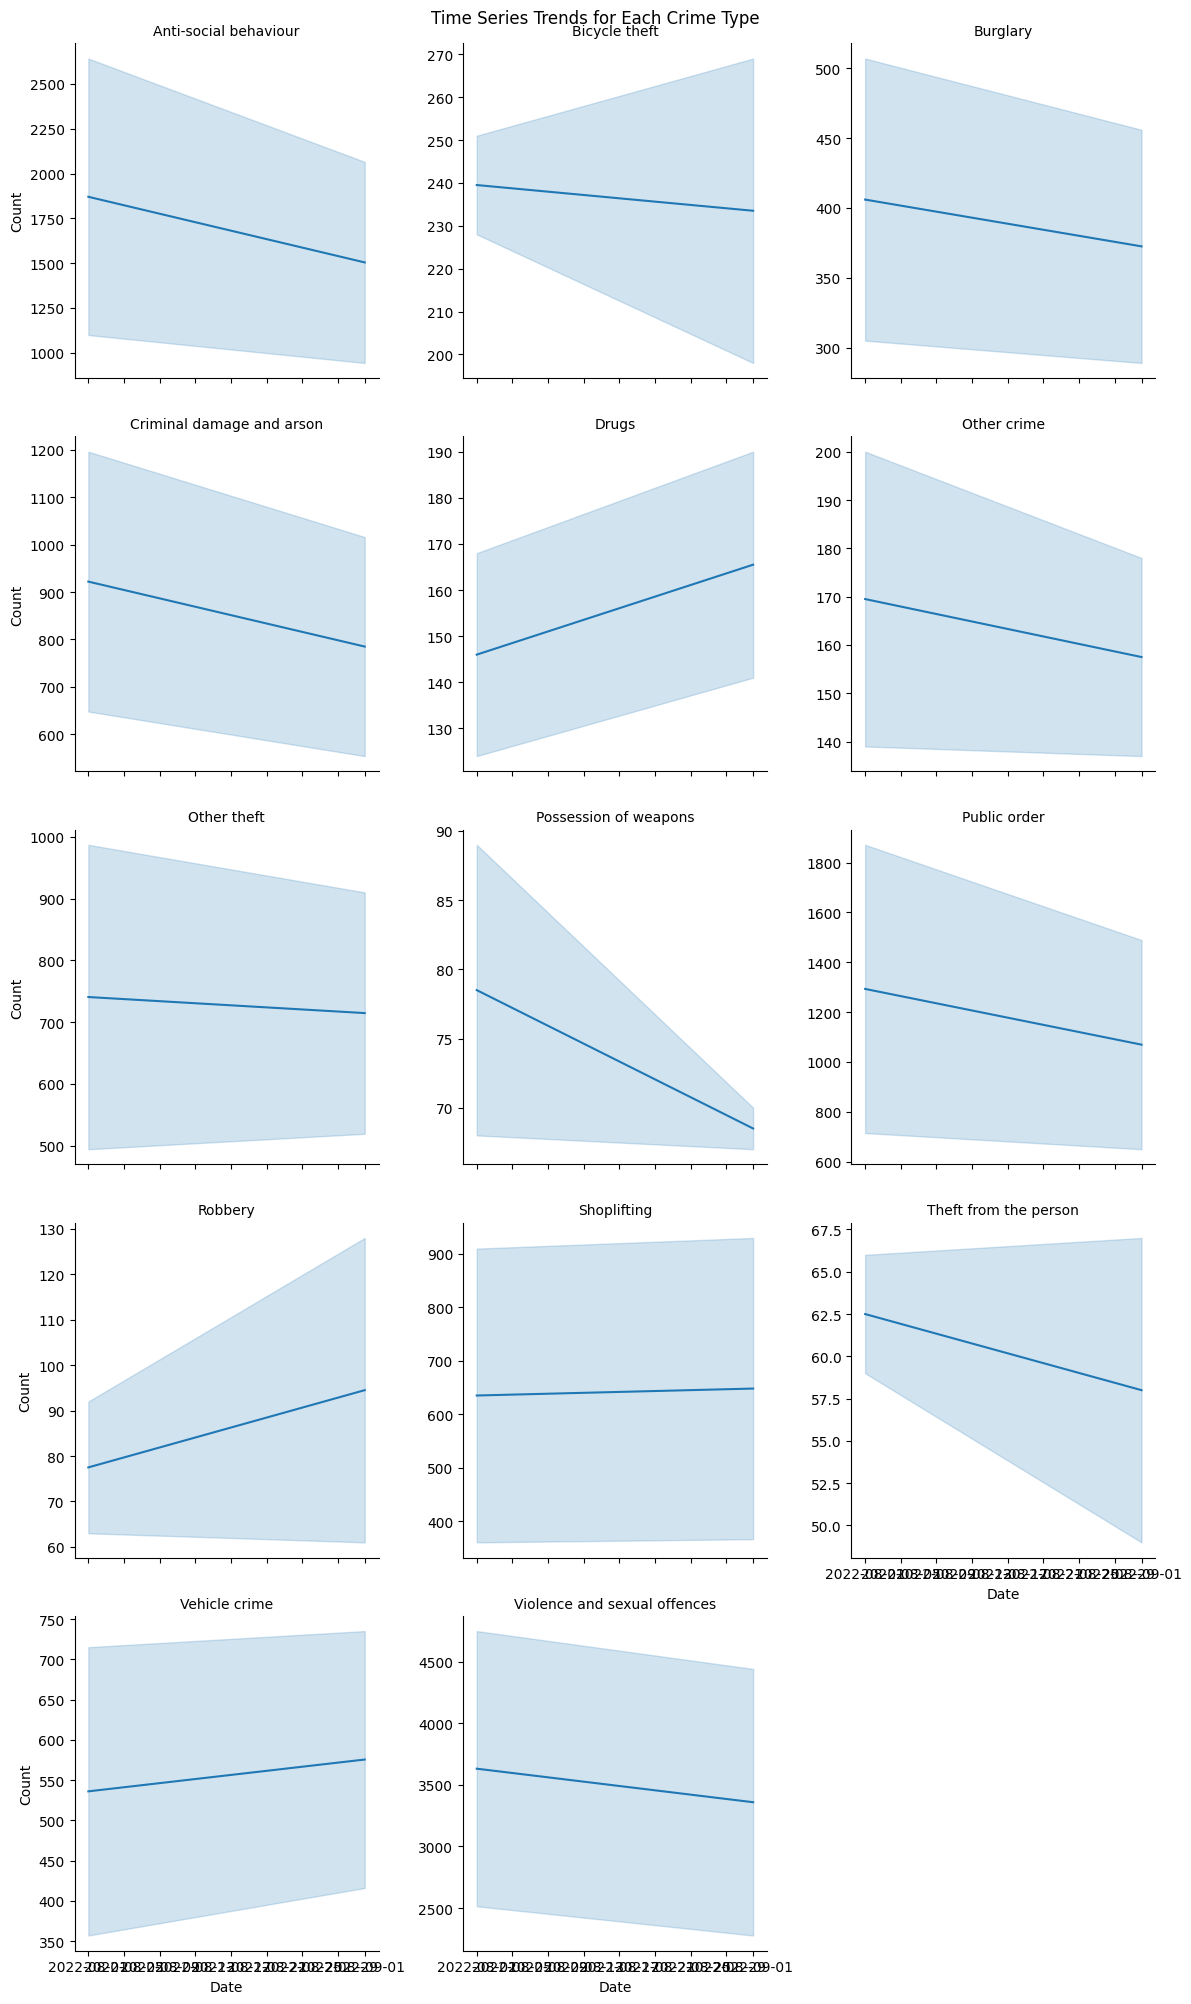

In [35]:
#Creating a grid with each graph showing each individal crime trend over time.
#The dark blue line represents the average rate, while the Light blue shade shows the range of highs and lows
df_crime_ts = df_crime.groupby(['Date','Reported by and Falls within', 'Crime type']).size().reset_index(name = 'Count')
df_crime_ts['Date'] = pd.to_datetime(df_crime_ts['Date'])
g = sns.FacetGrid(df_crime_ts, col = "Crime type", col_wrap = 3, height = 4, sharey = False)
g.map(sns.lineplot, "Date", "Count")
g.set_axis_labels("Date", "Count")
g.set_titles(col_template = "{col_name}")
g.fig.suptitle("Time Series Trends for Each Crime Type", y = 1)
plt.show()

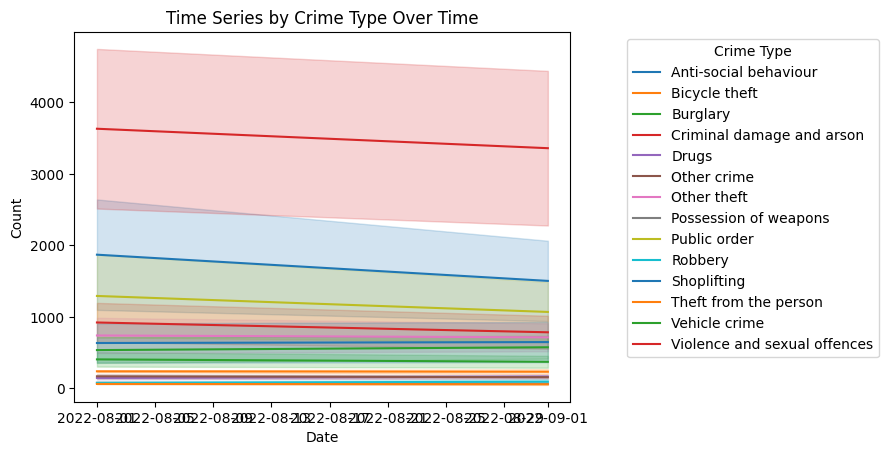

In [36]:
#Overlaying above plotted graphs within the same frame for better visual of crime type ranges in comparison with one another
df_crime_ts['Date'] = pd.to_datetime(df_crime_ts['Date'])
for crime_type, data in df_crime_ts.groupby('Crime type'):
    sns.lineplot(x = data['Date'], y = data['Count'], label = crime_type)
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Time Series by Crime Type Over Time')
plt.legend(title = 'Crime Type', bbox_to_anchor  = (1.1, 1), loc = 'upper left')
plt.show()

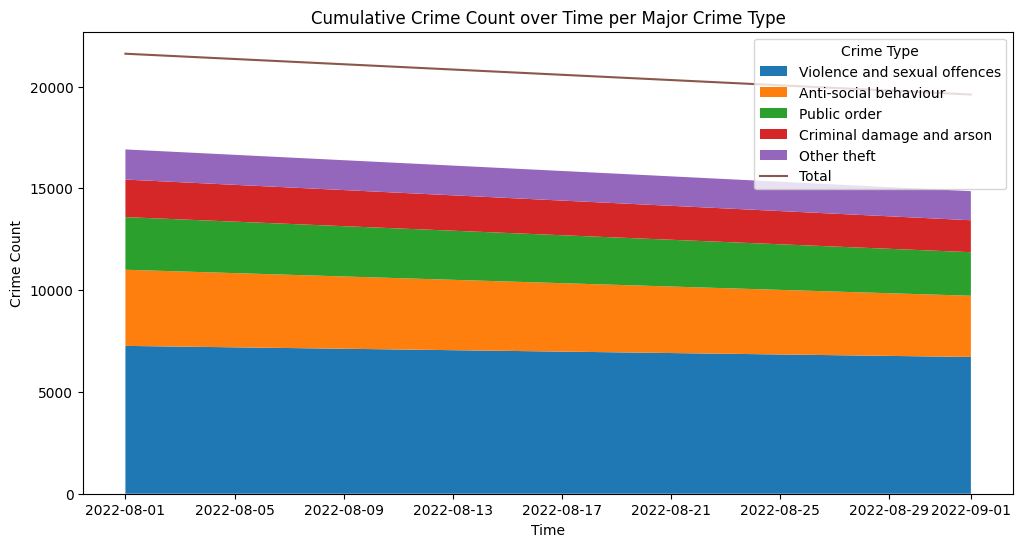

In [37]:
#Using Stackplot to show Cumulative Overview of Top 5 Crime Type over Time
df_crime.loc[:, 'Date'] = pd.to_datetime(df_crime['Date'])
df_crime.loc[:, 'Crime type'] = df_crime['Crime type'].astype(str)
time_series_per_crime = df_crime.pivot_table(index = 'Date', columns = 'Crime type', aggfunc = 'size', fill_value = 0)

top_crime_types = time_series_per_crime.sum().nlargest(5).index
time_series_top_crime = time_series_per_crime[top_crime_types]
total_crimes = time_series_per_crime.sum(axis = 1)

plt.figure(figsize = (12, 6))
plt.stackplot(time_series_top_crime.index, time_series_top_crime.values.T, labels = time_series_top_crime.columns)
plt.plot(total_crimes.index, total_crimes.values, label = 'Total')
plt.title('Cumulative Crime Count over Time per Major Crime Type')
plt.xlabel('Time')
plt.ylabel('Crime Count')
plt.legend(title = 'Crime Type', loc = 'upper right')
plt.show()

In [38]:
#Printing the Head of Data Frame including Date and Crime Type
print(df_crime[['GeneralDate', 'Crime type']].head())

  GeneralDate             Crime type
0     2022-08  Anti-social behaviour
1     2022-08  Anti-social behaviour
2     2022-08  Anti-social behaviour
3     2022-08  Anti-social behaviour
4     2022-08  Anti-social behaviour


In [39]:
#Printing the top and bottom 5 Districts and their respective crime count
top_5 = df_District.nlargest(5, 'Crime Count')
bottom_5 = df_District.nsmallest(5, 'Crime Count')

print("Top 5 districts:")
print(top_5[['District', 'Crime Count']])

print("\n")

print("Bottom 5 districtst:")
print(bottom_5[['District', 'Crime Count']])

Top 5 districts:
                 District  Crime Count
7                 Bristol        10531
56           Peterborough         4824
69  South Gloucestershire         3344
54         North Somerset         2941
9               Cambridge         2743


Bottom 5 districtst:
         District  Crime Count
0  Aylesbury Vale            1
2         Bedford            1
3          Bexley            1
4        Bradford            1
5           Brent            1


## <a name = 'Stop and Search Data' style="color:#000000;"> Stop and Search Data </a>

### Object Analysis

Here we are trying to investigate the distribution of crime types using the 'Crime type' variable to identify the most common and least common types of crimes.

In [40]:
df_search['Outcome'].unique()

array(['A no further action disposal', 'Khat or Cannabis warning',
       'Summons / charged by post', 'Community resolution', 'Arrest',
       'Caution (simple or conditional)'], dtype=object)

In [41]:
df_search.head()

,Type,Date,Part of a policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome_Severity
0,Person search,2022-08-01T00:49:00+00:00,NaN,51.46182,-2.563052,Male,over 34,NaN,White,Police and Criminal Evidence Act 1984 (section 1),Article for use in theft,A no further action disposal,Low Severity
2,Person search,2022-08-01T10:43:00+00:00,NaN,51.462213,-2.59101,Male,over 34,White - Any other White background,White,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal,Low Severity
3,Person search,2022-08-01T16:33:00+00:00,NaN,51.456677,-2.592162,Male,18-24,Mixed/Multiple ethnic groups - Any other Mixed...,Mixed,Police and Criminal Evidence Act 1984 (section 1),Articles for use in criminal damage,A no further action disposal,Low Severity
4,Person search,2022-08-01T16:40:00+00:00,NaN,51.345692,-2.972984,Female,25-34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,Low Severity
5,Person search,2022-08-01T16:40:00+00:00,NaN,51.494809,-2.59102,Female,over 34,White - English/Welsh/Scottish/Northern Irish/...,White,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal,Low Severity


### Bar Chart Analysis

In the below two graphs, we aim to view aspects of demographic is stop and search data. Is there any relationship between Age, Gender, and Ethnicity with respect to stop and search? How does the count of a bar chart help us identify these trends?

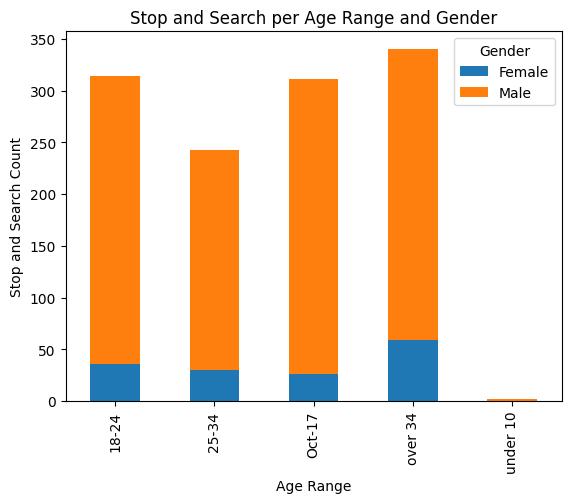

In [42]:
#Showing Stop and Search by Gender and Age Range
crime_counts = df_search.groupby(['Age range','Gender']).size().unstack()
crime_counts.plot(kind = 'bar', stacked = True)

plt.xlabel('Age Range')
plt.ylabel('Stop and Search Count')
plt.title('Stop and Search per Age Range and Gender')
plt.legend(title = 'Gender')
plt.show()

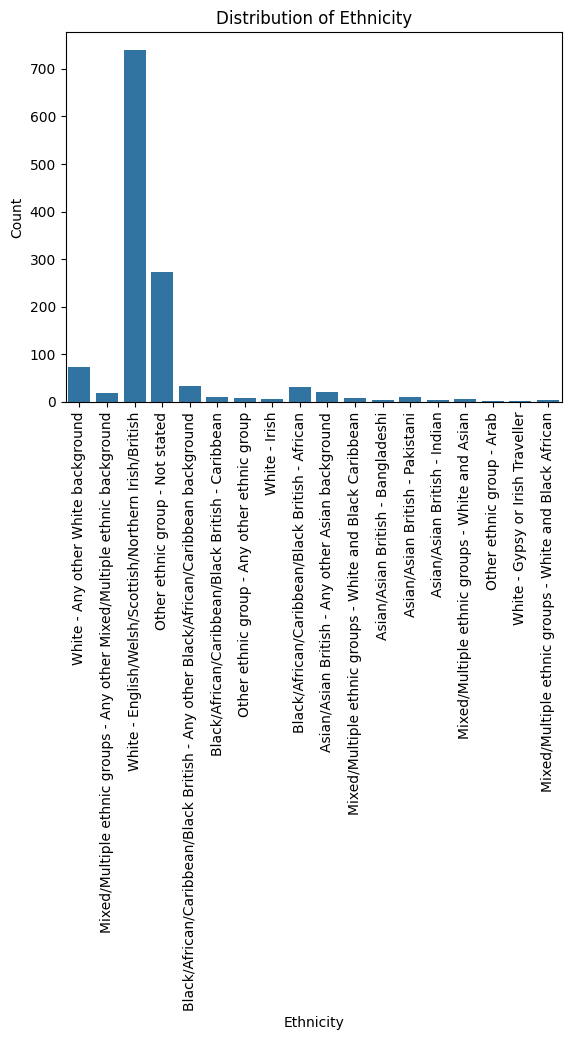

In [43]:
#Plotting Distribution of Stop and Search by Ethinicity
sns.countplot(x = 'Self-defined ethnicity', data = df_search)
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.title('Distribution of Ethnicity')
plt.xticks(rotation = 90)
plt.show()

## Histogram Analysis

In this graph, we aim to view the distributino of officer ethnicity. This histogram supports our intuition that most officers are white, since the most common race demographic of UK is mainly white.

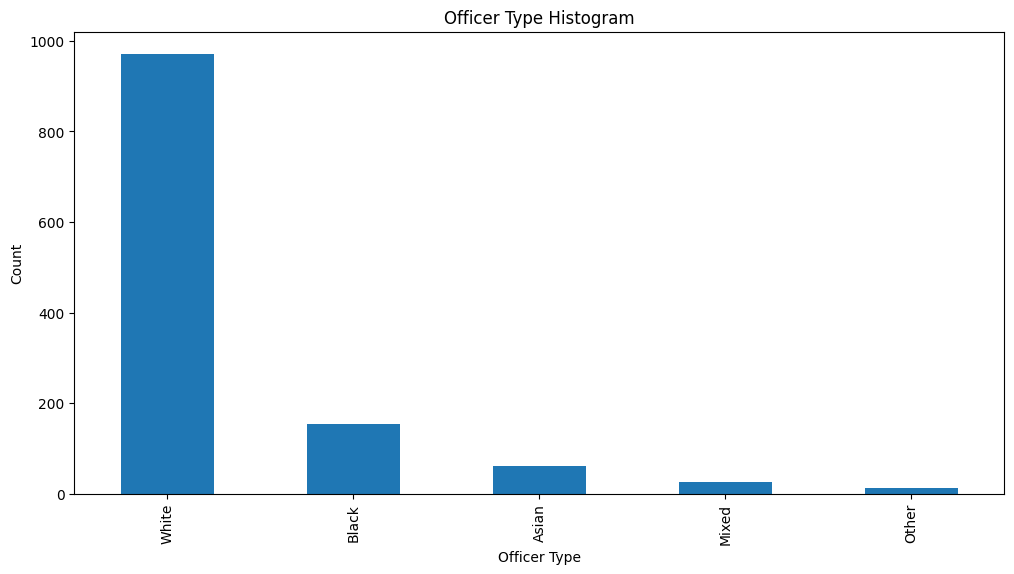

In [44]:
#Plotting distribution of Officer Type
crime_type = df_search['Officer-defined ethnicity'].value_counts()
crime_type.plot(kind = 'bar', figsize = (12, 6))
plt.title('Officer Type Histogram')
plt.xlabel('Officer Type')
plt.ylabel('Count')
plt.show()

The below graph is an interactive pie chart that helps visualise the count of stop and search object type in proportion to one another. Clicking on the legend selects/deslects different objectives, thus making it customisable.

In [45]:
#Interactive Pie Chart for top reasons of stop and search
pie_2 = df_search['Object of search'].value_counts().reset_index()
pie_2.columns = ['Object of search', 'Count']
fig = px.pie(pie_2, names = 'Object of search', values = 'Count', title = 'Objects of Search')
fig.show()

# <a name = 'Data Modeling and Prediction' style="color:#000000;"> Data Modeling and Prediction </a>

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load your datasets
df_crime = df_crime  # Replace with actual path
df_police = df_search  # Replace with actual path

# Merge datasets based on common attributes like Date, Longitude, Latitude

In [47]:
df_crime.columns

Index(['Date', 'Reported by and Falls within', 'Longitude', 'Latitude',
       'Location', 'LSOA code', 'LSOA name', 'Crime type', 'District',
       'GeneralDate'],
      dtype='object')

In [48]:
df_police.columns

Index(['Type', 'Date', 'Part of a policing operation', 'Latitude', 'Longitude',
       'Gender', 'Age range', 'Self-defined ethnicity',
       'Officer-defined ethnicity', 'Legislation', 'Object of search',
       'Outcome', 'Outcome_Severity'],
      dtype='object')

In [49]:
df_crime['Longitude'] = df_crime['Longitude'].astype(float)
df_police['Longitude'] = df_police['Longitude'].astype(float)
df_crime['Latitude'] = df_crime['Latitude'].astype(float)
df_police['Latitude'] = df_police['Latitude'].astype(float)
merged_df = pd.merge(df_crime, df_police, on=['Longitude', 'Latitude'])

# Select features and target variable
X = merged_df[['Crime type', 'Location', 'Self-defined ethnicity', 'Officer-defined ethnicity']]  # Example features
y = merged_df['Outcome']  # Example target variable

# Encode categorical variables
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize models
rf_model = RandomForestClassifier(random_state=42)
svm_model = SVC(kernel='rbf',random_state=42)
knn_model = KNeighborsClassifier()

# Train and evaluate Random Forest
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Train and evaluate SVM
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# Train and evaluate KNN
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

<ipython-input-49-ea0e69d6a4eb>:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-49-ea0e69d6a4eb>:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-49-ea0e69d6a4eb>:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-49-ea0e

Random Forest Accuracy: 0.7797400866377874
              precision    recall  f1-score   support

           0       0.80      0.91      0.86      1905
           1       0.71      0.56      0.62       705
           2       1.00      0.84      0.91        19
           3       0.70      0.56      0.62       192
           4       0.69      0.46      0.55       118
           5       0.79      0.44      0.56        62

    accuracy                           0.78      3001
   macro avg       0.78      0.63      0.69      3001
weighted avg       0.77      0.78      0.77      3001

SVM Accuracy: 0.6347884038653782
              precision    recall  f1-score   support

           0       0.63      1.00      0.78      1905
           1       0.00      0.00      0.00       705
           2       0.00      0.00      0.00        19
           3       0.00      0.00      0.00       192
           4       0.00      0.00      0.00       118
           5       0.00      0.00      0.00        62

 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [50]:
len(merged_df['Outcome'].unique().tolist())

6

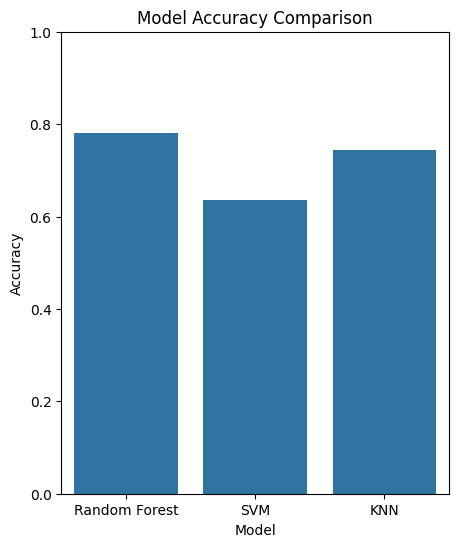

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



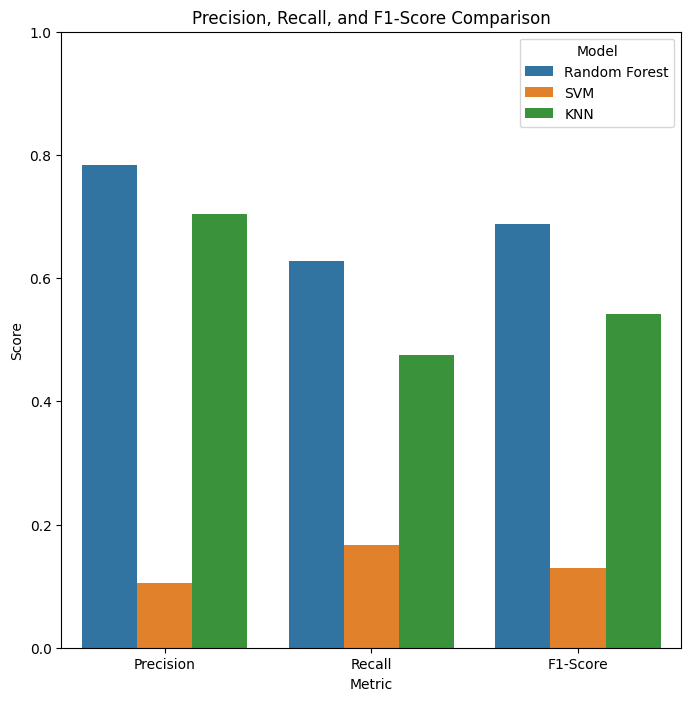

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

# Assuming y_pred_rf, y_pred_svm, y_pred_knn contain the predictions for each model
# And y_test contains the true labels

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Prepare accuracy data
accuracy_data = {
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Accuracy': [accuracy_rf, accuracy_svm, accuracy_knn]
}

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame(accuracy_data)

# Plot Accuracy
plt.figure(figsize=(5, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

# Calculate precision, recall, and F1-score for each model
prec_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='macro')
prec_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(y_test, y_pred_svm, average='macro')
prec_knn, recall_knn, f1_knn, _ = precision_recall_fscore_support(y_test, y_pred_knn, average='macro')

# Prepare precision, recall, and F1 data
metrics_data = {
    'Metric': ['Precision', 'Recall', 'F1-Score'] * 3,
    'Score': [prec_rf, recall_rf, f1_rf, prec_svm, recall_svm, f1_svm, prec_knn, recall_knn, f1_knn],
    'Model': ['Random Forest'] * 3 + ['SVM'] * 3 + ['KNN'] * 3
}

# Create a DataFrame for plotting
metrics_df = pd.DataFrame(metrics_data)

# Plot Precision, Recall, and F1-Score
plt.figure(figsize=(8, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df)
plt.title('Precision, Recall, and F1-Score Comparison')
plt.ylim(0, 1)
plt.show()


<ipython-input-52-27886ba2aeb0>:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-52-27886ba2aeb0>:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-52-27886ba2aeb0>:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-52-2788

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.6427 - loss: 1.2072 - val_accuracy: 0.6348 - val_loss: 1.0625
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6578 - loss: 1.0418 - val_accuracy: 0.6348 - val_loss: 1.0561
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6582 - loss: 1.0173 - val_accuracy: 0.6348 - val_loss: 1.0428
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6634 - loss: 1.0042 - val_accuracy: 0.6348 - val_loss: 1.0376
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6665 - loss: 0.9921 - val_accuracy: 0.6348 - val_loss: 1.0350
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6577 - loss: 1.0153 - val_accuracy: 0.6348 - val_loss: 1.0324
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6562 - loss: 1.0124 - val_accuracy: 0.6348 - val_loss: 1.0315
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6551 - loss: 1.0112 - val_a

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



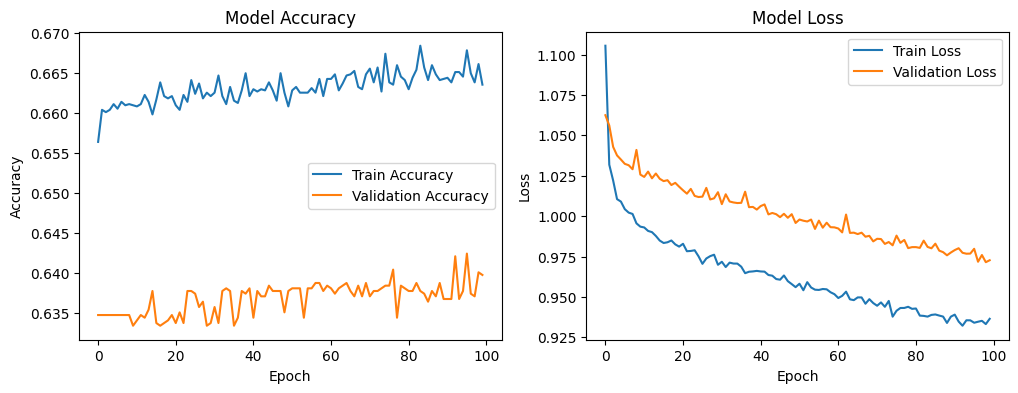

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
# Load your datasets
df_crime = df_crime
df_police = df_search
df_crime['Longitude'] = df_crime['Longitude'].astype(float)
df_police['Longitude'] = df_police['Longitude'].astype(float)
df_crime['Latitude'] = df_crime['Latitude'].astype(float)
df_police['Latitude'] = df_police['Latitude'].astype(float)

# Merge datasets based on common attributes like Date, Longitude, Latitude
merged_df = pd.merge(df_crime, df_police, on=['Longitude', 'Latitude'])

# Select features and target variable
X = merged_df[['Crime type', 'Location', 'Self-defined ethnicity', 'Officer-defined ethnicity']]  # Example features
y = merged_df['Outcome']  # Example target variable

# Encode categorical variables
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col])

# y = le.fit_transform(y)
# Encode the target variable as integers first
y = le.fit_transform(y)

# Convert `y` to one-hot encoding
y = to_categorical(y, num_classes=len(np.unique(y)))
# print(y)
# Normalize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape data for 1D CNN (samples, timesteps, features)
X = np.expand_dims(X, axis=2)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build the 1D CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(merged_df['Outcome'].unique().tolist()), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'CNN Accuracy: {accuracy}')

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability distributions to class labels
y_test_classes = np.argmax(y_test, axis=1)

# Print classification report
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))

# Plotting the Accuracy and Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6269 - loss: 1.2751 - val_accuracy: 0.6348 - val_loss: 1.0512
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6548 - loss: 1.0075 - val_accuracy: 0.6348 - val_loss: 1.0546
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6633 - loss: 0.9905 - val_accuracy: 0.6348 - val_loss: 1.0332
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6555 - loss: 0.9978 - val_accuracy: 0.6391 - val_loss: 1.0266
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6639 - loss: 0.9755 - val_accuracy: 0.6351 - val_loss: 1.0220
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6545 - loss: 0.9789 - val_accuracy: 0.6408 - val_loss: 1.0199
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6669 - loss: 0.9569 - val_accuracy: 0.6368 - val_loss: 1.0026
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6663 - loss: 0.9612 - val_acc

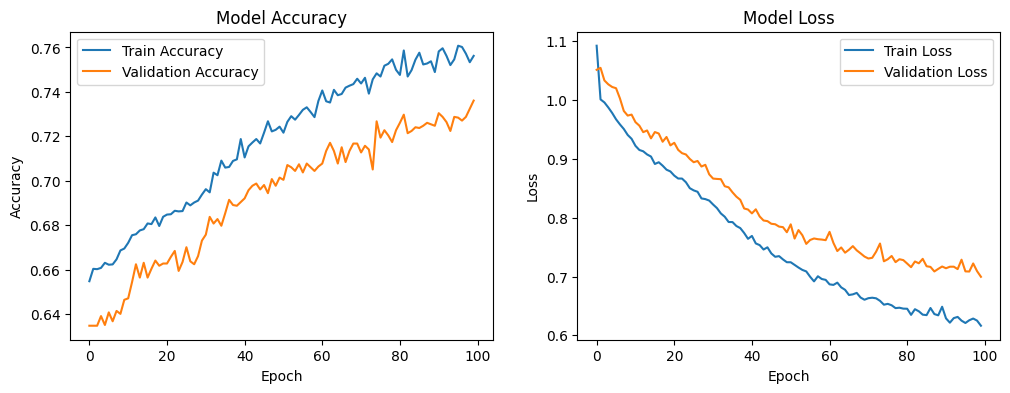

In [53]:

from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout


# Build the RNN model (SimpleRNN, LSTM, or GRU can be used)
model = Sequential()
model.add(LSTM(units=128, input_shape=(X_train.shape[1], 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=64))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(merged_df['Outcome'].unique().tolist()), activation='softmax'))  # Use softmax for multi-class classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'RNN Accuracy: {accuracy}')

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability distributions to class labels
y_test_classes = np.argmax(y_test, axis=1)

# Print classification report
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))

# Plotting the Accuracy and Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

